In [27]:
!pip install mapboxgl
!pip install cartopy
!pip install contextily
!pip install rasterio
!pip install cartopy
!pip install mpltern

zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip


In [2]:
# Import Modules
import pandas as pd
from pandas import json_normalize
import geopandas as gpd
import numpy as np
from datetime import datetime
from rasterio.plot import show
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

### Kano

In [3]:
results_grid = gpd.read_file("model-output.gpkg")
results_grid.head()

,grid_id,longitude,latitude,lon_min,lat_min,lon_max,lat_max,Accessibility_standard,result,focused,geometry
0,21,8.434492,11.962262,8.433978,11.961854,8.435005,11.962670,0.002805,1,0,"POLYGON ((8.43399 11.96267, 8.43501 11.96267, ..."
1,23,8.439753,11.972865,8.439239,11.972457,8.440267,11.973273,0.001370,1,0,"POLYGON ((8.43926 11.97327, 8.44027 11.97327, ..."
2,33,8.449757,11.967156,8.449243,11.966748,8.450270,11.967564,0.026098,0,1,"POLYGON ((8.44926 11.96756, 8.45027 11.96756, ..."
3,36,8.451083,11.983468,8.450570,11.983060,8.451597,11.983876,0.000319,2,0,"POLYGON ((8.45059 11.98388, 8.4516 11.98388, 8..."
4,44,8.453533,12.005490,8.453019,12.005082,8.454046,12.005898,0.000024,2,0,"POLYGON ((8.45303 12.0059, 8.45405 12.0059, 8...."


In [4]:
# Load the validation dataset
validation_df = pd.read_csv('2026-01-27T09_11_45+00_00_0912.csv')
print(validation_df.shape)
validation_df.head()

(90301, 14)


,id,created_at,validation,user_id,user_background,user_map_usage,output_id,output_model,output_model_city_name,output_model_city_country,output_model_subdomain_name,output_result,output_latitude,output_longitude
0,51c48ebe-f38f-4500-a80c-5ec1ac80bdca,2025-05-08T14:40:28.368385+00:00,1.0,a1c71b2b-d878-4e05-bae0-d4a1be92242b,['Just Browsing'],4.0,b37ec964-ce74-4c35-a465-12f8e97ff7bf,08a139b4-f2ef-4758-9969-860c7e889db0,Nairobi,Kenya,Accumulated Waste Piles,1,-1.286387,36.827204
1,0063f12d-3f04-47df-b7e0-3c55adbc09db,2025-05-22T12:36:28.908012+00:00,2.0,4466ebba-9700-4d0f-808d-a661cb693746,NaN,4.0,6e006408-ef2a-4b9c-bdac-15c737a14be7,6f38f125-0d6f-4b7f-9cb0-e3529e67da75,Kano,Nigeria,Morphological Informality,2,11.996518,8.508990
2,934f028f-6e1b-4029-ab07-f41b269b204e,2025-05-22T12:41:19.334276+00:00,1.0,15aa12bd-f20b-4a40-a1d8-5d57ae17eb1a,"['Just Browsing', 'Someone Different', 'gentle...",4.0,f80d0053-ede5-40fd-b2a6-dd1433d1eb1e,6f38f125-0d6f-4b7f-9cb0-e3529e67da75,Kano,Nigeria,Morphological Informality,0,11.993255,8.472513
3,651d9931-6988-429b-940c-a2c46cd445bc,2025-05-22T12:41:28.409779+00:00,1.0,15aa12bd-f20b-4a40-a1d8-5d57ae17eb1a,"['Just Browsing', 'Someone Different', 'gentle...",4.0,79d3eb25-b071-4613-9134-093cbb151e28,6f38f125-0d6f-4b7f-9cb0-e3529e67da75,Kano,Nigeria,Morphological Informality,0,11.994071,8.471518
4,936c8a66-c7de-4d67-922b-1ba05ba05f39,2025-05-22T12:41:32.881643+00:00,1.0,15aa12bd-f20b-4a40-a1d8-5d57ae17eb1a,"['Just Browsing', 'Someone Different', 'gentle...",4.0,162a97eb-3e5b-466d-93ff-a9e080943927,6f38f125-0d6f-4b7f-9cb0-e3529e67da75,Kano,Nigeria,Morphological Informality,0,11.994071,8.470506


In [5]:
# Select pilot city
pilot = 'Kano'  # Change this to the desired pilot city
# Load PAR data and filter by pilot city
par_expanded = validation_df[validation_df['output_model_city_name'] == f'{pilot.capitalize()}']

In [6]:
# Describe the shape of the validation data
print("Shape of PAR Data", par_expanded.shape)
par_expanded['output_model_subdomain_name'].value_counts()

Shape of PAR Data (24809, 14)


output_model_subdomain_name
Morphological Informality                      11009
Emergency Obstetric Care Access Deprivation     4434
General Healthcare Access Deprivation           4038
Road Access Deprivation                         3581
Drinking Water Access Deprivation               1747
Name: count, dtype: int64

In [7]:
# Enter subdomain
subdomain = 'Drinking Water Access Deprivation'  # Change this to the desired subdomain

# Filter Data by Subdomain
par_subdomain = par_expanded[par_expanded['output_model_subdomain_name'] == subdomain]
par_subdomain.head()

,id,created_at,validation,user_id,user_background,user_map_usage,output_id,output_model,output_model_city_name,output_model_city_country,output_model_subdomain_name,output_result,output_latitude,output_longitude
85708,d620d72d-86c5-4f4a-b941-ef93e4a78669,2025-10-29T10:59:40.594665+00:00,1.0,3e199a4c-7036-414a-9d8a-f221c5229a1f,['Community Member'],1.0,fb5ca328-c59d-4f76-9ab3-361de387c157,113d67d7-f1e2-468f-bd69-ef13006c5223,Kano,Nigeria,Drinking Water Access Deprivation,1,11.973681,8.463031
85714,7f4dc474-3547-4e4b-ba48-ec61124a0022,2025-10-29T10:59:42.959221+00:00,1.0,3e199a4c-7036-414a-9d8a-f221c5229a1f,['Community Member'],1.0,e0f6c0ef-d1a8-4ae4-b709-189656d2ce48,113d67d7-f1e2-468f-bd69-ef13006c5223,Kano,Nigeria,Drinking Water Access Deprivation,1,11.972865,8.463016
85715,48806da0-1f35-45a8-a360-373028821c57,2025-10-24T09:12:50.704973+00:00,1.0,4c0079ca-d0fa-48c7-9b0c-2bf2ae760ef9,['Just Browsing'],2.0,b2d8c77d-e24f-4353-89ae-c120a62b0c2c,113d67d7-f1e2-468f-bd69-ef13006c5223,Kano,Nigeria,Drinking Water Access Deprivation,1,11.994887,8.518061
85716,9591a96f-c6bc-4041-913c-0177e942dcc5,2025-10-24T09:14:07.678654+00:00,1.0,4c0079ca-d0fa-48c7-9b0c-2bf2ae760ef9,['Just Browsing'],2.0,df8964c9-e8e4-46b5-ba48-dbd5db618c88,113d67d7-f1e2-468f-bd69-ef13006c5223,Kano,Nigeria,Drinking Water Access Deprivation,1,11.995702,8.518077
85717,b31658ff-f07d-4228-8f00-6d18bd8531ff,2025-10-29T10:54:42.009989+00:00,2.0,6b96c10a-1d4d-4cfa-8e23-4b079f053035,['Research'],4.0,7e70a97f-da5d-44c2-83dc-9cbb2455b917,113d67d7-f1e2-468f-bd69-ef13006c5223,Kano,Nigeria,Drinking Water Access Deprivation,2,11.958184,8.494084


In [8]:
print(results_grid.shape)
print(results_grid.columns.tolist())
print('Accessibility_standard' in results_grid.columns)

if 'Accessibility_standard' in results_grid.columns:
    print(results_grid['Accessibility_standard'].describe())
    display(results_grid[['Accessibility_standard']].head())

(49063, 11)
['grid_id', 'longitude', 'latitude', 'lon_min', 'lat_min', 'lon_max', 'lat_max', 'Accessibility_standard', 'result', 'focused', 'geometry']
True
count    49063.000000
mean         0.003041
std          0.017836
min          0.000000
25%          0.000071
50%          0.000320
75%          0.001408
max          1.000000
Name: Accessibility_standard, dtype: float64


,Accessibility_standard
0,0.002805
1,0.001370
2,0.026098
3,0.000319
4,0.000024


In [11]:
val_majority = gpd.read_file ('par-majority-kano-DW.gpkg')
val_majority

,output_latitude,output_longitude,val_count_0,val_count_1,val_count_2,model,val_total,val_max,val_vary,val_majority,geometry
0,11.970418,8.468025,0,1,0,2,1,1,0,1,"POLYGON ((8.46753 11.97083, 8.46854 11.97083, ..."
1,11.975312,8.469131,0,2,0,2,2,2,0,1,"POLYGON ((8.46863 11.97572, 8.46964 11.97572, ..."
2,11.932902,8.468312,0,1,0,2,1,1,0,1,"POLYGON ((8.46781 11.93331, 8.46883 11.93331, ..."
3,11.981021,8.470253,0,1,0,2,1,1,0,1,"POLYGON ((8.46976 11.98143, 8.47077 11.98143, ..."
4,11.958184,8.470823,1,0,0,1,1,1,0,0,"POLYGON ((8.47032 11.95859, 8.47134 11.95859, ..."
...,...,...,...,...,...,...,...,...,...,...,...
1469,11.961447,8.526512,0,0,1,2,1,1,0,2,"POLYGON ((8.52601 11.96185, 8.52703 11.96185, ..."
1470,11.960631,8.526496,0,0,1,2,1,1,0,2,"POLYGON ((8.526 11.96104, 8.52701 11.96104, 8...."
1471,11.959815,8.526480,0,0,1,2,1,1,0,2,"POLYGON ((8.52598 11.96022, 8.52699 11.96022, ..."
1472,11.961447,8.527524,0,0,1,2,1,1,0,2,"POLYGON ((8.52703 11.96185, 8.52804 11.96185, ..."


In [12]:
# Make copies
results_grid2 = results_grid.copy()
val_majority2 = val_majority.copy()

# Round coordinates to consistent precision
results_grid2["lon_key"] = results_grid2["longitude"].round(6)
results_grid2["lat_key"] = results_grid2["latitude"].round(6)

val_majority2["lon_key"] = val_majority2["output_longitude"].round(6)
val_majority2["lat_key"] = val_majority2["output_latitude"].round(6)

# Merge on coordinate keys
Accessibility_index_val_majority = val_majority2.merge(
    results_grid2[["grid_id", "lon_key", "lat_key", "Accessibility_standard", "result", "focused"]],
    on=["lon_key", "lat_key"],
    how="left"
)

print("Joined rows:", len(Accessibility_index_val_majority))
print("Missing Accessibility_standard:", Accessibility_index_val_majority["Accessibility_standard"].isna().sum())

Accessibility_index_val_majority.head()

Joined rows: 1474
Missing Accessibility_standard: 0


,output_latitude,output_longitude,val_count_0,val_count_1,val_count_2,model,val_total,val_max,val_vary,val_majority,geometry,lon_key,lat_key,grid_id,Accessibility_standard,result,focused
0,11.970418,8.468025,0,1,0,2,1,1,0,1,"POLYGON ((8.46753 11.97083, 8.46854 11.97083, ...",8.468025,11.970418,122,0.000317,2,1
1,11.975312,8.469131,0,2,0,2,2,2,0,1,"POLYGON ((8.46863 11.97572, 8.46964 11.97572, ...",8.469131,11.975312,135,0.000217,2,1
2,11.932902,8.468312,0,1,0,2,1,1,0,1,"POLYGON ((8.46781 11.93331, 8.46883 11.93331, ...",8.468312,11.932902,136,0.000023,2,1
3,11.981021,8.470253,0,1,0,2,1,1,0,1,"POLYGON ((8.46976 11.98143, 8.47077 11.98143, ...",8.470253,11.981021,146,0.000209,2,1
4,11.958184,8.470823,1,0,0,1,1,1,0,0,"POLYGON ((8.47032 11.95859, 8.47134 11.95859, ...",8.470823,11.958184,155,0.000432,1,1


In [13]:
kano_calib = Accessibility_index_val_majority.copy()

print("Calibration cells:", len(kano_calib))
display(kano_calib[['val_majority', 'model', 'grid_id', 'Accessibility_standard', 'result']].head())

Calibration cells: 1474


,val_majority,model,grid_id,Accessibility_standard,result
0,1,2,122,0.000317,2
1,1,2,135,0.000217,2
2,1,2,136,0.000023,2
3,1,2,146,0.000209,2
4,0,1,155,0.000432,1


In [14]:
display(
    kano_calib.groupby('val_majority')['Accessibility_standard'].describe()
)

display(
    kano_calib.groupby('val_majority')['Accessibility_standard']
    .quantile([0.1, 0.25, 0.5, 0.75, 0.9])
    .unstack()
)

,count,mean,std,min,25%,50%,75%,max
val_majority,,,,,,,,
0,512.0,0.000611,0.001681,0.000006,0.000059,0.000203,0.000441,0.010974
1,684.0,0.000555,0.001299,0.000004,0.000042,0.000201,0.000333,0.012002
2,278.0,0.000116,0.000656,0.000002,0.000020,0.000038,0.000083,0.010887


,0.10,0.25,0.50,0.75,0.90
val_majority,,,,,
0,0.000018,0.000059,0.000203,0.000441,0.000511
1,0.000019,0.000042,0.000201,0.000333,0.001565
2,0.000013,0.000020,0.000038,0.000083,0.000193


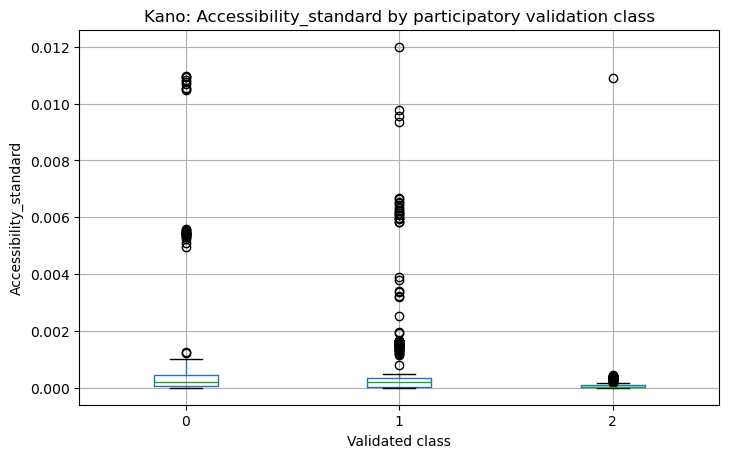

In [15]:
kano_calib.boxplot(column='Accessibility_standard', by='val_majority', figsize=(8,5))
plt.title('Kano: Accessibility_standard by participatory validation class')
plt.suptitle('')
plt.xlabel('Validated class')
plt.ylabel('Accessibility_standard')
plt.show()

In [17]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report

df = kano_calib[['Accessibility_standard', 'val_majority', 'model']].copy()
df['Accessibility_standard'] = df['Accessibility_standard'].astype(float)
df['val_majority'] = df['val_majority'].astype(int)

# candidate thresholds from the observed distribution
candidates = np.unique(np.quantile(df['Accessibility_standard'], np.linspace(0.05, 0.95, 181)))

def classify_from_thresholds(x, t1, t2):
    if x <= t1:
        return 2   # High deprivation
    elif x <= t2:
        return 1   # Medium deprivation
    else:
        return 0   # Low deprivation

best = None
rows = []

for i, t1 in enumerate(candidates[:-1]):
    for t2 in candidates[i+1:]:
        y_pred = df['Accessibility_standard'].apply(lambda x: classify_from_thresholds(x, t1, t2))
        macro_f1 = f1_score(df['val_majority'], y_pred, average='macro')
        acc = accuracy_score(df['val_majority'], y_pred)
        rows.append((t1, t2, macro_f1, acc))
        
        if best is None or macro_f1 > best['macro_f1'] or (
            macro_f1 == best['macro_f1'] and acc > best['acc']
        ):
            best = {'t1': t1, 't2': t2, 'macro_f1': macro_f1, 'acc': acc}

search_results = pd.DataFrame(rows, columns=['t1', 't2', 'macro_f1', 'acc'])
search_results = search_results.sort_values(['macro_f1', 'acc'], ascending=False)

print("Best thresholds:")
print(best)

display(search_results.head(10))

Best thresholds:
{'t1': 5.3205793862521404e-05, 't2': 0.0003908400775352189, 'macro_f1': 0.4752078009022613, 'acc': 0.4864314789687924}


,t1,t2,macro_f1,acc
8755,0.000053,0.000391,0.475208,0.486431
8747,0.000053,0.000354,0.474276,0.480326
8877,0.000055,0.000391,0.474127,0.485075
8632,0.000052,0.000391,0.473576,0.485075
8754,0.000053,0.000386,0.473533,0.483718
9355,0.000061,0.000391,0.473205,0.483039
8869,0.000055,0.000354,0.473131,0.478969
8748,0.000053,0.000360,0.473021,0.479647
9237,0.000059,0.000391,0.473011,0.483039
8750,0.000053,0.000368,0.473009,0.481004


In [18]:
t1 = best['t1']
t2 = best['t2']

kano_calib['model_v2'] = kano_calib['Accessibility_standard'].apply(
    lambda x: 2 if x <= t1 else (1 if x <= t2 else 0)
)

y_true = kano_calib['val_majority'].astype(int)
y_pred_v1 = kano_calib['model'].astype(int)
y_pred_v2 = kano_calib['model_v2'].astype(int)

cm_v1 = confusion_matrix(y_true, y_pred_v1, labels=[0, 1, 2])
cm_v2 = confusion_matrix(y_true, y_pred_v2, labels=[0, 1, 2])

acc_v1 = accuracy_score(y_true, y_pred_v1)
acc_v2 = accuracy_score(y_true, y_pred_v2)

f1_v1 = f1_score(y_true, y_pred_v1, average='macro')
f1_v2 = f1_score(y_true, y_pred_v2, average='macro')

print("Kano V1")
print(cm_v1)
print("Accuracy:", round(acc_v1, 3))
print("Macro F1:", round(f1_v1, 3))

print("\nKano V2")
print(cm_v2)
print("Accuracy:", round(acc_v2, 3))
print("Macro F1:", round(f1_v2, 3))

print("\nClassification report for Kano V2")
print(classification_report(
    y_true, y_pred_v2,
    labels=[0, 1, 2],
    target_names=['Low', 'Medium', 'High'],
    digits=3
))

Kano V1
[[  0 151 361]
 [  0 108 576]
 [  0   3 275]]
Accuracy: 0.26
Macro F1: 0.199

Kano V2
[[175 222 115]
 [119 364 201]
 [  8  92 178]]
Accuracy: 0.486
Macro F1: 0.475

Classification report for Kano V2
              precision    recall  f1-score   support

         Low      0.579     0.342     0.430       512
      Medium      0.537     0.532     0.535       684
        High      0.360     0.640     0.461       278

    accuracy                          0.486      1474
   macro avg      0.492     0.505     0.475      1474
weighted avg      0.518     0.486     0.484      1474

